# M16 · Dimensionality Reduction — ✍️ Toy Examples, Step by Tiny Step

**Companion to lesson M16. Written for someone new to ML.**

Dimensionality reduction means turning a table with many **features** (input columns) into a table with fewer new features while keeping the useful pattern. We use it for **visualization** (draw a 2D map), **denoising** (drop weak noisy directions), **speed** (fewer numbers to compute), and sometimes **anomaly detection** (weird points reconstruct badly). Every section below has a marked **Toy example**, prints the numbers, and draws a picture. Run top to bottom; no internet or downloads are needed.

**What you'll do:**
- See why high dimensions are tricky: the **curse of dimensionality**, visualization, denoising, and speed.
- Build **PCA** by hand: center → covariance → eigenvectors → projection → explained variance.
- Reconstruct from fewer PCA components and use the error for denoising.
- Use **t-SNE** for nonlinear 2D visualization and learn where **UMAP** fits conceptually.
- Flag an injected anomaly with PCA reconstruction error and IsolationForest.

## Step 0 · Setup

Import NumPy (arrays), pandas (small tables), Matplotlib (pictures), and scikit-learn helpers. Fix the **seed** so the printed numbers are reproducible, and define a tiny `log()` helper.

[setup] tools ready — NumPy + pandas + scikit-learn + Matplotlib imported, seed fixed to 0


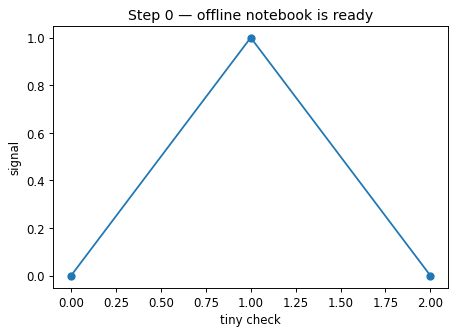

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest

np.random.seed(0)
plt.rcParams["figure.figsize"] = (6, 4)

def log(label, value):
    print(f"[{label}] {value}")

log("setup", "tools ready — NumPy + pandas + scikit-learn + Matplotlib imported, seed fixed to 0")
plt.plot([0, 1, 2], [0, 1, 0], marker="o")
plt.title("Step 0 — offline notebook is ready")
plt.xlabel("tiny check")
plt.ylabel("signal")
plt.show()

---
# Part A · Why reduce dimensions?

## Step 1 · Toy example — the curse of dimensionality makes distances less informative

The **curse of dimensionality** is a family of problems that appear when the number of features grows. A tiny numeric symptom: in high-dimensional random data, many pairwise distances become similar, so "nearest" and "farther" are less dramatic than in 2D.

[D=2: min/mean/max distance] [0.009, 0.52, 1.213]
[D=2: distance spread ÷ mean] 0.4633
[D=10: min/mean/max distance] [0.469, 1.272, 2.103]
[D=10: distance spread ÷ mean] 0.2032
[D=50: min/mean/max distance] [2.068, 2.853, 3.699]
[D=50: distance spread ÷ mean] 0.0862
[D=200: min/mean/max distance] [5.071, 5.834, 6.743]
[D=200: distance spread ÷ mean] 0.041
[distance summary table] 
 dimensions    min   mean    max  spread_over_mean
          2 0.0087 0.5199 1.2129            0.4633
         10 0.4687 1.2718 2.1026            0.2032
         50 2.0678 2.8532 3.6992            0.0862
        200 5.0714 5.8343 6.7429            0.0410


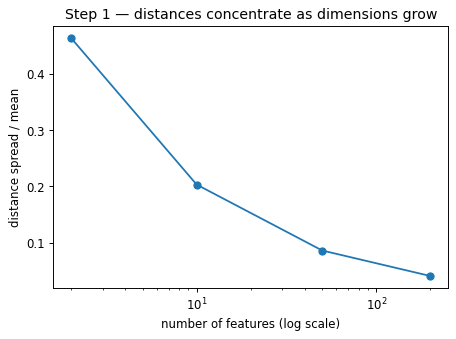

In [5]:
rng = np.random.RandomState(0)
dims = [2, 10, 50, 200]
cv_by_dim = {}
rows = []
for D in dims:
    U = rng.rand(160, D)                         # 160 points, D features, values in [0, 1]
    sample = U[:60]                              # keep the calculation tiny
    d = np.sqrt(((sample[:, None, :] - sample[None, :, :]) ** 2).sum(axis=2))
    vals = d[np.triu_indices(len(sample), k=1)]  # all unique pairwise distances
    cv = float(vals.std() / vals.mean())         # coefficient of variation = spread / average
    cv_by_dim[D] = cv
    rows.append([D, vals.min(), vals.mean(), vals.max(), cv])
    log(f"D={D}: min/mean/max distance", np.round([vals.min(), vals.mean(), vals.max()], 3).tolist())
    log(f"D={D}: distance spread ÷ mean", round(cv, 4))

summary = pd.DataFrame(rows, columns=["dimensions", "min", "mean", "max", "spread_over_mean"])
log("distance summary table", "\n" + summary.round(4).to_string(index=False))
assert abs(cv_by_dim[200] - 0.040983241088190056) < 1e-12
assert cv_by_dim[2] > cv_by_dim[10] > cv_by_dim[50] > cv_by_dim[200]

plt.plot(dims, [cv_by_dim[D] for D in dims], marker="o")
plt.xscale("log")
plt.title("Step 1 — distances concentrate as dimensions grow")
plt.xlabel("number of features (log scale)")
plt.ylabel("distance spread / mean")
plt.show()

## Step 2 · Toy example — fewer columns are easier to draw and faster to compute

A model table with 6 features cannot be shown on one ordinary 2D scatter plot. Reducing it to 2 new coordinates gives a map. Fewer columns also means fewer arithmetic operations: touching an $n \times D$ matrix costs about $nD$ number reads.

[raw table shape] 5 rows × 6 features
[reduced map shape] 5 rows × 2 features
[numbers touched before] 30
[numbers touched after] 10
[speed intuition ratio] 3.0× fewer numbers
[10 bins per feature grid cells] {1: 10, 2: 100, 3: 1000, 6: 1000000}


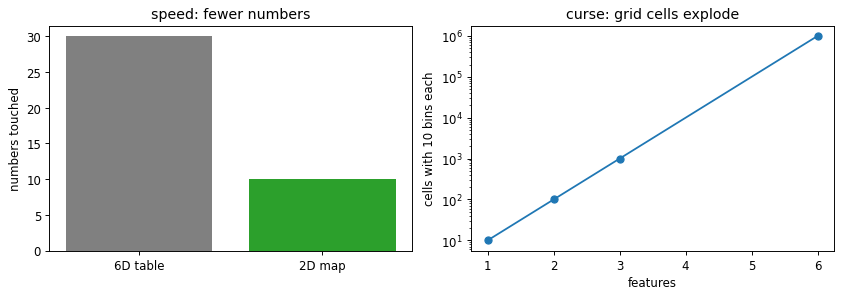

In [7]:
n_rows = 5
before_features = ["age", "clicks", "likes", "shares", "views", "minutes"]
after_features = ["map_x", "map_y"]
before_ops = n_rows * len(before_features)
after_ops = n_rows * len(after_features)
cell_counts = {D: 10 ** D for D in [1, 2, 3, 6]}

log("raw table shape", f"{n_rows} rows × {len(before_features)} features")
log("reduced map shape", f"{n_rows} rows × {len(after_features)} features")
log("numbers touched before", before_ops)
log("numbers touched after", after_ops)
log("speed intuition ratio", f"{before_ops / after_ops:.1f}× fewer numbers")
log("10 bins per feature grid cells", cell_counts)
assert before_ops == 30 and after_ops == 10
assert cell_counts[6] == 1_000_000

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].bar(["6D table", "2D map"], [before_ops, after_ops], color=["gray", "tab:green"])
ax[0].set_title("speed: fewer numbers")
ax[0].set_ylabel("numbers touched")
ax[1].plot(list(cell_counts.keys()), list(cell_counts.values()), marker="o")
ax[1].set_yscale("log")
ax[1].set_title("curse: grid cells explode")
ax[1].set_xlabel("features")
ax[1].set_ylabel("cells with 10 bins each")
plt.tight_layout(); plt.show()

## Step 3 · Toy example — denoising by keeping the strong direction

A **signal** is the pattern we care about; **noise** is random wiggle. If the real pattern is mostly along one line, projecting points back onto that line can reduce noise. PCA will learn this line automatically later.

[true points] [[-2.0, -2.0], [-1.0, -1.0], [0.0, 0.0], [1.0, 1.0], [2.0, 2.0]]
[noisy points] [[-2.0, -1.5], [-1.0, -1.4], [0.0, 0.3], [1.0, 0.4], [2.0, 2.4]]
[manual 1D scores on diagonal] [-2.475, -1.697, 0.212, 0.99, 3.111]
[mean squared error before] 0.204
[mean squared error after projection] 0.102


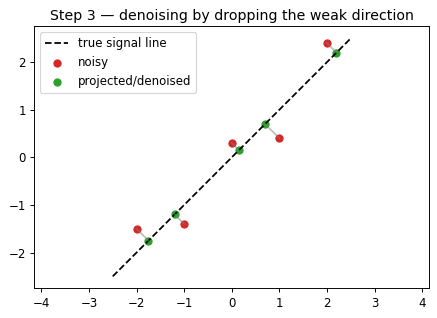

In [9]:
true_line = np.array([[-2, -2], [-1, -1], [0, 0], [1, 1], [2, 2]], float)
noise = np.array([[0, 0.5], [0, -0.4], [0, 0.3], [0, -0.6], [0, 0.4]], float)
noisy = true_line + noise
unit_diag = np.array([1, 1], float) / np.sqrt(2)
scores_manual = noisy @ unit_diag
simple_denoised = np.outer(scores_manual, unit_diag)
noise_error = float(np.mean(np.sum((noisy - true_line) ** 2, axis=1)))
denoised_error = float(np.mean(np.sum((simple_denoised - true_line) ** 2, axis=1)))

log("true points", true_line.tolist())
log("noisy points", np.round(noisy, 2).tolist())
log("manual 1D scores on diagonal", np.round(scores_manual, 3).tolist())
log("mean squared error before", round(noise_error, 3))
log("mean squared error after projection", round(denoised_error, 3))
assert abs(noise_error - 0.204) < 1e-12
assert abs(denoised_error - 0.102) < 1e-12
assert denoised_error < noise_error

plt.plot([-2.5, 2.5], [-2.5, 2.5], "k--", label="true signal line")
plt.scatter(noisy[:,0], noisy[:,1], c="tab:red", label="noisy")
plt.scatter(simple_denoised[:,0], simple_denoised[:,1], c="tab:green", label="projected/denoised")
for a, b in zip(noisy, simple_denoised):
    plt.plot([a[0], b[0]], [a[1], b[1]], color="gray", alpha=0.5)
plt.title("Step 3 — denoising by dropping the weak direction")
plt.axis("equal"); plt.legend(); plt.show()

**Good for:** making a 2D map, removing weak noise, speeding up later models, and summarizing many correlated features.  
**Watch out for:** losing rare but important information; "fewer dimensions" is helpful only if the kept directions preserve the task-relevant signal.

---
# Part B · PCA by hand

## Step 4 · Toy example — a tiny diagonal dataset for PCA

**PCA** means **Principal Component Analysis**. It finds new axes called **principal components**: the first axis captures the most variance (spread), the second captures the next most, and so on. Our toy points mostly lie along a diagonal, so one component should explain almost everything.

[X_pca shape] (8, 2)
[X_pca points] [[-3.0, -2.8], [-2.0, -2.1], [-1.0, -0.9], [0.0, 0.2], [1.0, 0.9], [2.0, 2.2], [3.0, 2.8], [4.0, 4.1]]
[feature ranges] [7.0, 6.9]


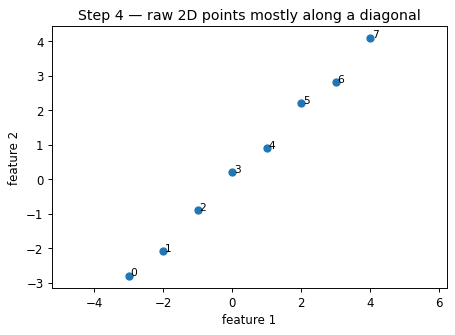

In [13]:
X_pca = np.array([[-3.0, -2.8], [-2.0, -2.1], [-1.0, -0.9], [0.0, 0.2],
                  [1.0, 0.9], [2.0, 2.2], [3.0, 2.8], [4.0, 4.1]], float)
log("X_pca shape", X_pca.shape)
log("X_pca points", X_pca.tolist())
log("feature ranges", np.round([X_pca[:,0].ptp(), X_pca[:,1].ptp()], 3).tolist())
assert X_pca.shape == (8, 2)

plt.scatter(X_pca[:,0], X_pca[:,1], c="tab:blue")
for i, (x, y) in enumerate(X_pca):
    plt.text(x + 0.05, y, str(i), fontsize=9)
plt.title("Step 4 — raw 2D points mostly along a diagonal")
plt.xlabel("feature 1"); plt.ylabel("feature 2"); plt.axis("equal"); plt.show()

## Step 5 · Toy example — center the data first

PCA starts by subtracting the **mean** (average point). Centering moves the cloud so its middle is at `(0, 0)`. The covariance formula is $C = \frac{1}{n-1}X_c^\top X_c$, where $X_c$ means "centered X".

[mean of original data] [0.5, 0.55]
[first 3 centered rows] [[-3.5, -3.35], [-2.5, -2.65], [-1.5, -1.45]]
[mean after centering] [0.0, 0.0]


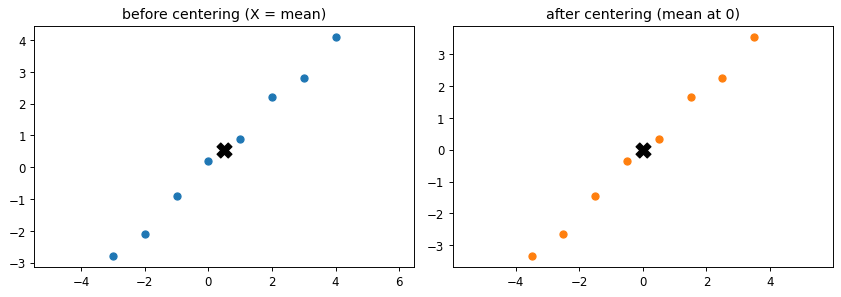

In [15]:
mean_pca = X_pca.mean(axis=0)
X_centered = X_pca - mean_pca
centered_mean = X_centered.mean(axis=0)
log("mean of original data", np.round(mean_pca, 6).tolist())
log("first 3 centered rows", np.round(X_centered[:3], 3).tolist())
log("mean after centering", np.round(centered_mean, 12).tolist())
assert np.allclose(mean_pca, [0.5, 0.55])
assert np.allclose(centered_mean, [0, 0])

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].scatter(X_pca[:,0], X_pca[:,1], c="tab:blue"); ax[0].scatter(*mean_pca, marker="X", s=160, c="black")
ax[0].set_title("before centering (X = mean)"); ax[0].axis("equal")
ax[1].scatter(X_centered[:,0], X_centered[:,1], c="tab:orange"); ax[1].scatter(0, 0, marker="X", s=160, c="black")
ax[1].set_title("after centering (mean at 0)"); ax[1].axis("equal")
plt.tight_layout(); plt.show()

## Step 6 · Toy example — compute the 2×2 covariance matrix

A **covariance** measures whether two features move together. Big positive off-diagonal covariance means "when feature 1 is high, feature 2 is usually high too." That is exactly what a diagonal cloud has.

[covariance matrix] 
          feature1  feature2
feature1  6.000000  5.914286
feature2  5.914286  5.854286
[variance of feature 1] 6.0
[variance of feature 2] 5.854286
[covariance feature1-feature2] 5.914286


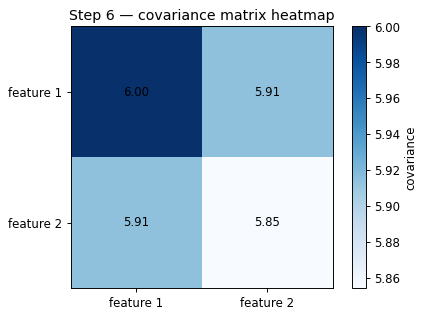

In [17]:
cov_pca = (X_centered.T @ X_centered) / (len(X_centered) - 1)
log("covariance matrix", "\n" + pd.DataFrame(cov_pca, columns=["feature1", "feature2"], index=["feature1", "feature2"]).round(6).to_string())
log("variance of feature 1", round(cov_pca[0,0], 6))
log("variance of feature 2", round(cov_pca[1,1], 6))
log("covariance feature1-feature2", round(cov_pca[0,1], 6))
assert abs(cov_pca[0, 0] - 6.0) < 1e-12
assert abs(cov_pca[0, 1] - 5.914285714285715) < 1e-12

plt.imshow(cov_pca, cmap="Blues")
plt.xticks([0, 1], ["feature 1", "feature 2"])
plt.yticks([0, 1], ["feature 1", "feature 2"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cov_pca[i,j]:.2f}", ha="center", va="center")
plt.colorbar(label="covariance")
plt.title("Step 6 — covariance matrix heatmap")
plt.show()

## Step 7 · Toy example — eigenvectors are PCA directions

An **eigenvector** of the covariance matrix points in a direction whose variance is summarized by its **eigenvalue**. PCA sorts eigenvectors from largest eigenvalue to smallest. The largest one is the first principal component.

[sorted eigenvalues] [11.841877, 0.012408]
[sorted eigenvectors (columns are PCs)] [[0.711448, 0.702738], [0.702738, -0.711448]]
[explained-variance ratio] [0.998953, 0.001047]
[ratio sum] 1.0


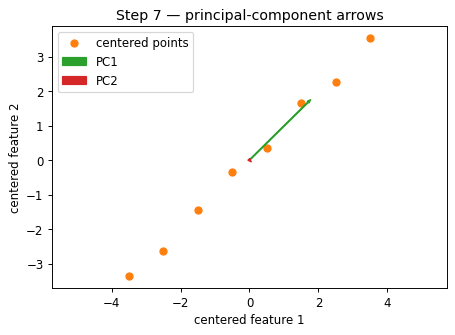

In [19]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_pca)       # eigh is for symmetric matrices like covariance
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]
for j in range(eigenvectors.shape[1]):                    # fix signs so printed values are stable
    if eigenvectors[0, j] < 0:
        eigenvectors[:, j] *= -1
explained_ratio = eigenvalues / eigenvalues.sum()

log("sorted eigenvalues", np.round(eigenvalues, 6).tolist())
log("sorted eigenvectors (columns are PCs)", np.round(eigenvectors, 6).tolist())
log("explained-variance ratio", np.round(explained_ratio, 6).tolist())
log("ratio sum", explained_ratio.sum())
assert abs(eigenvalues[0] - 11.84187731216866) < 1e-6
assert abs(eigenvalues[1] - 0.012408402117053687) < 1e-6
assert abs(explained_ratio.sum() - 1.0) < 1e-12
assert explained_ratio[0] > 0.998

plt.scatter(X_centered[:,0], X_centered[:,1], c="tab:orange", label="centered points")
origin = np.array([0, 0])
scale = 2.5
for j, color in enumerate(["tab:green", "tab:red"]):
    vec = eigenvectors[:, j] * np.sqrt(eigenvalues[j]) * scale / np.sqrt(eigenvalues[0])
    plt.arrow(origin[0], origin[1], vec[0], vec[1], color=color, width=0.025, length_includes_head=True, label=f"PC{j+1}")
plt.title("Step 7 — principal-component arrows")
plt.xlabel("centered feature 1"); plt.ylabel("centered feature 2")
plt.axis("equal"); plt.legend(); plt.show()

## Step 8 · Toy example — project 2D points down to 1D

A **projection** asks: "where does each point land on this new axis?" For PCA, the top-1 coordinate is $z = X_c w_1$, where $w_1$ is the first eigenvector.

[all PCA coordinates [PC1, PC2]] [[-4.8442, -0.0762], [-3.6409, 0.1285], [-2.0861, -0.0225], [-0.6017, -0.1024], [0.6017, 0.1024], [2.2267, -0.1198], [3.3598, 0.1561], [4.9848, -0.0661]]
[top-1 projected coordinates] [-4.8442, -3.6409, -2.0861, -0.6017, 0.6017, 2.2267, 3.3598, 4.9848]
[top-1 range] 9.829


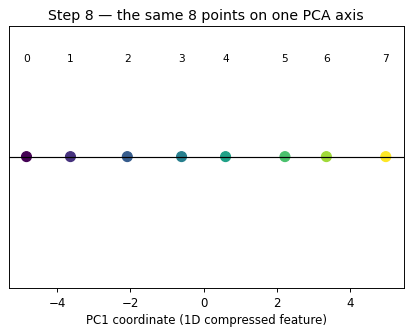

In [21]:
scores = X_centered @ eigenvectors
one_d = scores[:, 0]
log("all PCA coordinates [PC1, PC2]", np.round(scores, 4).tolist())
log("top-1 projected coordinates", np.round(one_d, 4).tolist())
log("top-1 range", round(float(one_d.max() - one_d.min()), 4))
assert abs(one_d[0] - (-4.844242847813147)) < 1e-9
assert abs(one_d[-1] - 4.984790497671091) < 1e-9

plt.scatter(one_d, np.zeros_like(one_d), c=np.arange(len(one_d)), cmap="viridis", s=70)
for i, z in enumerate(one_d):
    plt.text(z, 0.04, str(i), ha="center", fontsize=9)
plt.axhline(0, color="black", linewidth=1)
plt.yticks([])
plt.title("Step 8 — the same 8 points on one PCA axis")
plt.xlabel("PC1 coordinate (1D compressed feature)")
plt.show()

## Step 9 · Toy example — scree plot and explained variance

A **scree plot** shows how much variance each component explains. The **explained-variance ratio** is a fraction: 0.80 means "this component explains 80% of the spread."

[component 1 ratio] 0.998953
[component 2 ratio] 0.001047
[cumulative ratios] [0.998953, 1.0]


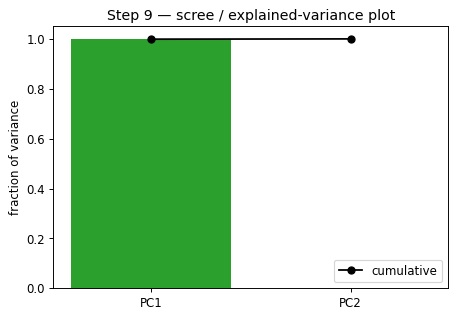

In [23]:
cumulative_ratio = np.cumsum(explained_ratio)
log("component 1 ratio", round(float(explained_ratio[0]), 6))
log("component 2 ratio", round(float(explained_ratio[1]), 6))
log("cumulative ratios", np.round(cumulative_ratio, 6).tolist())
assert abs(float(explained_ratio[0]) - 0.9989532560277251) < 1e-6
assert abs(float(cumulative_ratio[-1]) - 1.0) < 1e-12

plt.bar(["PC1", "PC2"], explained_ratio, color=["tab:green", "tab:red"])
plt.plot(["PC1", "PC2"], cumulative_ratio, color="black", marker="o", label="cumulative")
plt.ylim(0, 1.05)
plt.title("Step 9 — scree / explained-variance plot")
plt.ylabel("fraction of variance")
plt.legend(); plt.show()

**Good for:** linear, global compression when many features are correlated; quick 2D/3D views; preprocessing before simple models.  
**Watch out for:** PCA is **linear** and uses variance, so it can miss curved structure or rare low-variance signals that matter.

---
# Part C · PCA reconstruction and denoising

## Step 10 · Toy example — reconstruct points from only 1 component

A **reconstruction** maps reduced coordinates back to the original feature space. With one component, the formula is $\hat{X} = z_1 w_1^\top + \mu$, where $\mu$ is the mean. The gap between $X$ and $\hat{X}$ is reconstruction error.

[first 3 reconstructed points] [[-2.9464, -2.8542], [-2.0903, -2.0086], [-0.9842, -0.916]]
[reconstruction error per point] [0.005811, 0.01651, 0.000507, 0.010478, 0.010478, 0.014348, 0.024363, 0.004364]
[mean reconstruction error] 0.010857


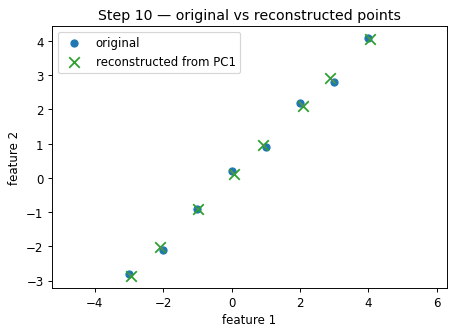

In [27]:
X_recon_1 = scores[:, [0]] @ eigenvectors[:, [0]].T + mean_pca
recon_error_each = np.sum((X_pca - X_recon_1) ** 2, axis=1)
mean_recon_error = float(recon_error_each.mean())
log("first 3 reconstructed points", np.round(X_recon_1[:3], 4).tolist())
log("reconstruction error per point", np.round(recon_error_each, 6).tolist())
log("mean reconstruction error", round(mean_recon_error, 6))
assert abs(mean_recon_error - 0.01085735185242201) < 1e-12

plt.scatter(X_pca[:,0], X_pca[:,1], c="tab:blue", label="original")
plt.scatter(X_recon_1[:,0], X_recon_1[:,1], c="tab:green", marker="x", s=80, label="reconstructed from PC1")
for a, b in zip(X_pca, X_recon_1):
    plt.plot([a[0], b[0]], [a[1], b[1]], color="gray", alpha=0.5)
plt.title("Step 10 — original vs reconstructed points")
plt.xlabel("feature 1"); plt.ylabel("feature 2")
plt.axis("equal"); plt.legend(); plt.show()

## Step 11 · Toy example — error rises when you drop components

Dropping components is compression. More compression usually means more error. With 2 components in a 2D dataset, PCA can reconstruct the original points almost exactly; with 0 components, everything becomes the mean.

[k=0: mean squared reconstruction error] 10.3725
[k=1: mean squared reconstruction error] 0.0108573519
[k=2: mean squared reconstruction error] 0.0


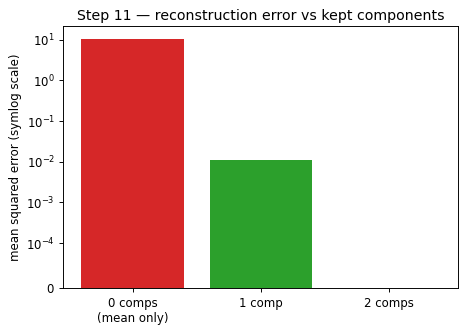

In [29]:
error_by_k = {}
for k in [0, 1, 2]:
    if k == 0:
        X_hat_k = np.repeat(mean_pca[None, :], len(X_pca), axis=0)
    else:
        X_hat_k = scores[:, :k] @ eigenvectors[:, :k].T + mean_pca
    error_by_k[k] = float(np.mean(np.sum((X_pca - X_hat_k) ** 2, axis=1)))
    log(f"k={k}: mean squared reconstruction error", round(error_by_k[k], 10))

assert abs(error_by_k[0] - 10.3725) < 1e-12
assert abs(error_by_k[1] - 0.01085735185242201) < 1e-12
assert error_by_k[2] < 1e-20
assert error_by_k[0] > error_by_k[1] > error_by_k[2]

plt.bar(["0 comps\n(mean only)", "1 comp", "2 comps"], [error_by_k[k] for k in [0, 1, 2]], color=["tab:red", "tab:green", "tab:blue"])
plt.yscale("symlog", linthresh=1e-4)
plt.title("Step 11 — reconstruction error vs kept components")
plt.ylabel("mean squared error (symlog scale)")
plt.show()

## Step 12 · Toy example — PCA denoising on many noisy diagonal points

Now we let scikit-learn's PCA learn the line from data. We keep 1 component, reconstruct, and compare to the hidden clean line we used to make the toy data.

[learned PCA direction] [0.7134, 0.7008]
[variance kept by 1 component] 0.968925
[error before PCA denoising] 0.206936
[error after PCA denoising] 0.001251


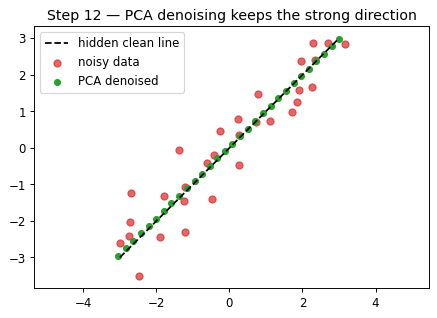

In [31]:
rng = np.random.RandomState(1)
t = np.linspace(-3, 3, 30)
clean = np.column_stack([t, t])
perp = np.array([1, -1], float) / np.sqrt(2)
noise = rng.normal(0, 0.45, size=len(t))[:, None] * perp[None, :]
noisy_cloud = clean + noise
pca_denoise = PCA(n_components=1, random_state=0).fit(noisy_cloud)
denoised_cloud = pca_denoise.inverse_transform(pca_denoise.transform(noisy_cloud))
error_noisy = float(np.mean(np.sum((noisy_cloud - clean) ** 2, axis=1)))
error_denoised = float(np.mean(np.sum((denoised_cloud - clean) ** 2, axis=1)))

log("learned PCA direction", np.round(pca_denoise.components_[0], 4).tolist())
log("variance kept by 1 component", round(float(pca_denoise.explained_variance_ratio_[0]), 6))
log("error before PCA denoising", round(error_noisy, 6))
log("error after PCA denoising", round(error_denoised, 6))
assert abs(error_noisy - 0.20693554285235424) < 1e-12
assert abs(error_denoised - 0.0012508483800691423) < 1e-12
assert error_denoised < error_noisy / 100

plt.plot(clean[:,0], clean[:,1], "k--", label="hidden clean line")
plt.scatter(noisy_cloud[:,0], noisy_cloud[:,1], c="tab:red", alpha=0.7, label="noisy data")
plt.scatter(denoised_cloud[:,0], denoised_cloud[:,1], c="tab:green", s=25, label="PCA denoised")
plt.title("Step 12 — PCA denoising keeps the strong direction")
plt.axis("equal"); plt.legend(); plt.show()

**Good for:** removing small random wiggles around a strong linear pattern and storing fewer numbers.  
**Watch out for:** if the "noise" direction contains a rare but important signal, reconstruction can erase it.

---
# Part D · Nonlinear embedding for visualization: t-SNE and UMAP

## Step 13 · Toy example — three clusters hiding in 8 dimensions

An **embedding** is a new representation of points. Here we make 3 clear clusters in 8D. A normal 2D scatter can show only two columns, so it may hide structure that lives in other columns.

[X8 shape] (45, 8)
[cluster counts] [15, 15, 15]
[first row (8 features)] [2.74, 2.71, -0.03, -0.23, 0.39, -0.38, -0.4, -0.15]


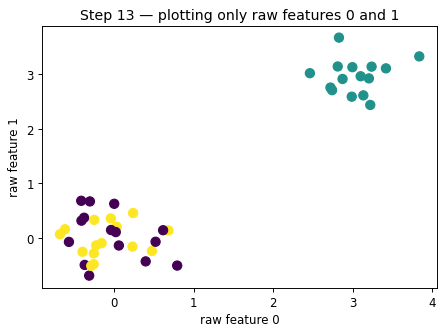

In [35]:
centers_8d = np.array([[0, 0, 0, 0, 0, 0, 0, 0],
                       [3, 3, 0, 0, 0, 0, 0, 0],
                       [0, 0, 3, 3, 3, 3, 0, 0]], float)
X8, y8 = make_blobs(n_samples=[15, 15, 15], centers=centers_8d, cluster_std=0.35, random_state=0)
counts = [int((y8 == k).sum()) for k in range(3)]
log("X8 shape", X8.shape)
log("cluster counts", counts)
log("first row (8 features)", np.round(X8[0], 2).tolist())
assert X8.shape == (45, 8)
assert counts == [15, 15, 15]

plt.scatter(X8[:,0], X8[:,1], c=y8, cmap="viridis", s=60)
plt.title("Step 13 — plotting only raw features 0 and 1")
plt.xlabel("raw feature 0"); plt.ylabel("raw feature 1")
plt.show()

## Step 14 · Toy example — PCA gives a linear, global 2D map

PCA is **LINEAR**: each new coordinate is a weighted sum of original features. It is also **global**: it tries to explain overall variance, not just tiny neighborhoods.

[PCA 8D→2D explained ratios] [0.743011, 0.20126]
[PCA 2D silhouette by true labels] 0.871422
[first PCA map coordinate] [-3.059, 1.096]


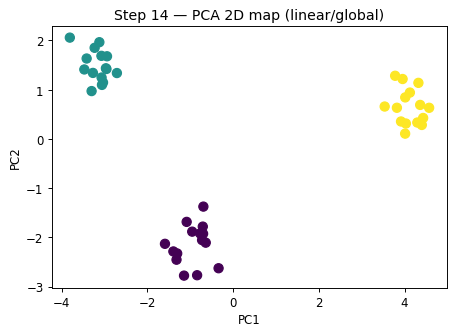

In [37]:
pca_8d = PCA(n_components=2, random_state=0).fit(X8)
X8_pca2 = pca_8d.transform(X8)
pca8_ratio = pca_8d.explained_variance_ratio_
pca8_sil = float(silhouette_score(X8_pca2, y8))
log("PCA 8D→2D explained ratios", np.round(pca8_ratio, 6).tolist())
log("PCA 2D silhouette by true labels", round(pca8_sil, 6))
log("first PCA map coordinate", np.round(X8_pca2[0], 3).tolist())
assert abs(float(pca8_ratio.sum()) - 0.9442709331055591) < 1e-9
assert pca8_sil > 0.85

plt.scatter(X8_pca2[:,0], X8_pca2[:,1], c=y8, cmap="viridis", s=60)
plt.title("Step 14 — PCA 2D map (linear/global)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

## Step 15 · Toy example — t-SNE gives a nonlinear local-neighborhood map

PCA is **LINEAR & global** while **t-SNE/UMAP are NONLINEAR & preserve LOCAL neighborhoods**. That means t-SNE/UMAP try to keep nearby points near each other in 2D, even if the original pattern bends or uses many features.

**UMAP note:** `umap-learn` is not preinstalled in Colab, so this notebook demos the same local-neighborhood visualization idea with scikit-learn's `TSNE`. Conceptually, UMAP builds a neighbor graph, then lays that graph out in low dimensions; it is often faster than t-SNE and can preserve more global structure, but it requires the extra `umap-learn` package.

[t-SNE embedding shape] (45, 2)
[t-SNE cluster centers] [[-10.644000053405762, -21.83799934387207], [24.172000885009766, -3.9839999675750732], [-15.722000122070312, 16.27199935913086]]
[center-to-center distances] [[0.0, 39.12699890136719, 38.446998596191406], [39.12699890136719, 0.0, 44.742000579833984], [38.446998596191406, 44.742000579833984, 0.0]]
[nearest-neighbor same-label fraction] 1.0
[t-SNE 2D silhouette by true labels] 0.92374


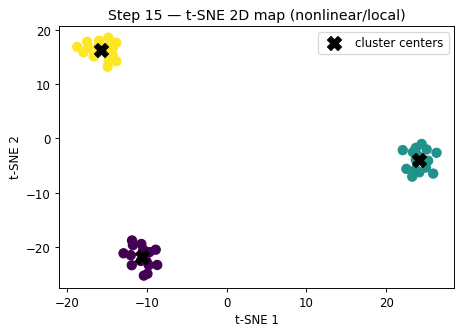

In [39]:
tsne = TSNE(n_components=2, perplexity=8, init="pca", learning_rate="auto", random_state=0)
X8_tsne2 = tsne.fit_transform(X8)
cluster_centers_tsne = np.vstack([X8_tsne2[y8 == k].mean(axis=0) for k in range(3)])
center_distances = np.sqrt(((cluster_centers_tsne[:, None, :] - cluster_centers_tsne[None, :, :]) ** 2).sum(axis=2))
point_distances = np.sqrt(((X8_tsne2[:, None, :] - X8_tsne2[None, :, :]) ** 2).sum(axis=2))
np.fill_diagonal(point_distances, np.inf)
nearest = point_distances.argmin(axis=1)
nearest_same_label = float(np.mean(y8[nearest] == y8))
tsne_sil = float(silhouette_score(X8_tsne2, y8))

log("t-SNE embedding shape", X8_tsne2.shape)
log("t-SNE cluster centers", np.round(cluster_centers_tsne, 3).tolist())
log("center-to-center distances", np.round(center_distances, 3).tolist())
log("nearest-neighbor same-label fraction", round(nearest_same_label, 3))
log("t-SNE 2D silhouette by true labels", round(tsne_sil, 6))
assert X8_tsne2.shape == (45, 2)
assert nearest_same_label == 1.0
assert tsne_sil > 0.85

plt.scatter(X8_tsne2[:,0], X8_tsne2[:,1], c=y8, cmap="viridis", s=60)
plt.scatter(cluster_centers_tsne[:,0], cluster_centers_tsne[:,1], c="black", marker="X", s=140, label="cluster centers")
plt.title("Step 15 — t-SNE 2D map (nonlinear/local)")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.legend(); plt.show()

**Good for:** visualizing local neighborhoods and cluster-like structure in 2D.  
**Watch out for:** t-SNE/UMAP plots are mainly for visualization; axis units are not original features, and distances between far-apart clusters can be misleading.

---
# Part E · Anomaly detection via reduction

## Step 16 · Toy example — inject one clear outlier

An **anomaly** is a point that does not fit the usual pattern. We create normal points near a diagonal line, then inject one obvious outlier far away from that line.

[normal points] 24
[outlier index] 24
[outlier coordinates] [0.0, -4.0]


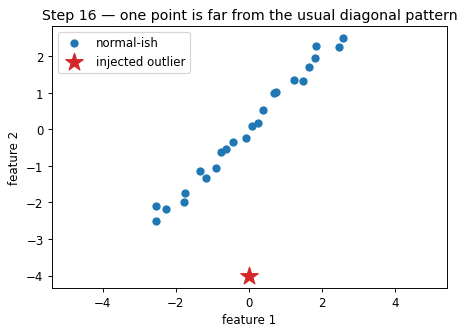

In [43]:
rng = np.random.RandomState(2)
t = np.linspace(-2.5, 2.5, 24)
normal = np.column_stack([t, t]) + rng.normal(0, 0.12, size=(24, 2))
outlier = np.array([[0.0, -4.0]])
X_anom = np.vstack([normal, outlier])
outlier_index = len(X_anom) - 1
log("normal points", len(normal))
log("outlier index", outlier_index)
log("outlier coordinates", X_anom[outlier_index].tolist())
assert outlier_index == 24

plt.scatter(X_anom[:-1,0], X_anom[:-1,1], c="tab:blue", label="normal-ish")
plt.scatter(X_anom[-1:,0], X_anom[-1:,1], c="tab:red", marker="*", s=240, label="injected outlier")
plt.title("Step 16 — one point is far from the usual diagonal pattern")
plt.xlabel("feature 1"); plt.ylabel("feature 2")
plt.axis("equal"); plt.legend(); plt.show()

## Step 17 · Toy example — PCA reconstruction error as an anomaly score

If normal data is mostly 1D, PCA with 1 component reconstructs normal points well. A point far from that line has a big **reconstruction error**, so we can use the error as an **anomaly score**.

[PCA anomaly direction] [0.6573, 0.7537]
[PCA reconstruction scores] [0.112, 0.364, 0.126, 0.009, 0.058, 0.107, 0.007, 0.003, 0.052, 0.033, 0.025, 0.001, 0.004, 0.0, 0.016, 0.035, 0.038, 0.0, 0.035, 0.003, 0.001, 0.028, 0.102, 0.054, 6.597]
[threshold = mean + 2 std] 2.882
[flagged indices] [24]


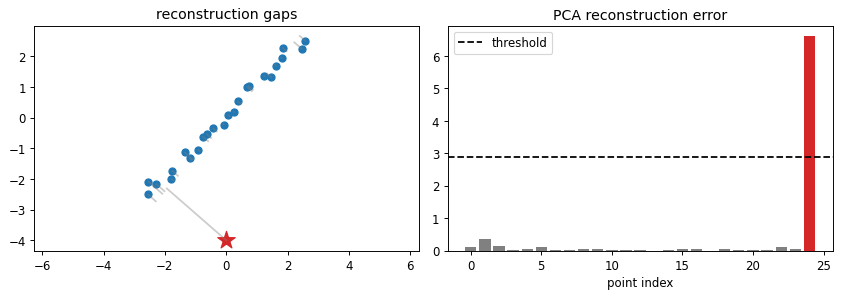

In [45]:
pca_anom = PCA(n_components=1, random_state=0).fit(X_anom)
X_anom_hat = pca_anom.inverse_transform(pca_anom.transform(X_anom))
pca_anom_score = np.sum((X_anom - X_anom_hat) ** 2, axis=1)
threshold = float(pca_anom_score.mean() + 2 * pca_anom_score.std())
pca_flags = np.where(pca_anom_score > threshold)[0]
log("PCA anomaly direction", np.round(pca_anom.components_[0], 4).tolist())
log("PCA reconstruction scores", np.round(pca_anom_score, 3).tolist())
log("threshold = mean + 2 std", round(threshold, 3))
log("flagged indices", pca_flags.tolist())
assert int(pca_anom_score.argmax()) == outlier_index
assert abs(float(pca_anom_score[outlier_index]) - 6.596821894512084) < 1e-9
assert pca_flags.tolist() == [outlier_index]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].scatter(X_anom[:,0], X_anom[:,1], c="tab:blue")
ax[0].scatter(X_anom[outlier_index,0], X_anom[outlier_index,1], c="tab:red", marker="*", s=240)
for a, b in zip(X_anom, X_anom_hat):
    ax[0].plot([a[0], b[0]], [a[1], b[1]], color="gray", alpha=0.4)
ax[0].set_title("reconstruction gaps")
ax[0].axis("equal")
ax[1].bar(np.arange(len(X_anom)), pca_anom_score, color=["tab:red" if i == outlier_index else "gray" for i in range(len(X_anom))])
ax[1].axhline(threshold, color="black", linestyle="--", label="threshold")
ax[1].set_title("PCA reconstruction error")
ax[1].set_xlabel("point index")
ax[1].legend()
plt.tight_layout(); plt.show()

## Step 18 · Toy example — IsolationForest flags the same outlier

**IsolationForest** is another anomaly detector. It randomly splits the data; unusual points tend to get isolated in fewer splits. We compare it to the PCA score on the same toy data.

[IsolationForest scores] [0.608, 0.54, 0.518, 0.483, 0.49, 0.478, 0.471, 0.477, 0.458, 0.462, 0.454, 0.444, 0.453, 0.449, 0.479, 0.463, 0.457, 0.486, 0.49, 0.498, 0.503, 0.522, 0.575, 0.612, 0.65]
[IsolationForest flagged indices] [24]
[IsolationForest outlier score] 0.65031


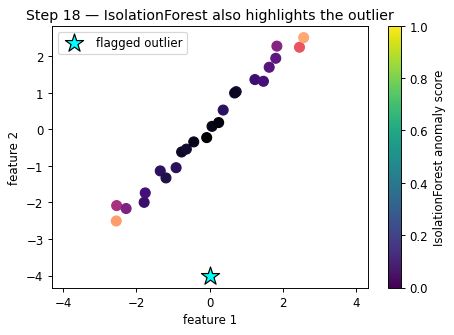

In [47]:
iso = IsolationForest(n_estimators=100, contamination=1/len(X_anom), random_state=0).fit(X_anom)
iso_score = -iso.score_samples(X_anom)       # larger = more unusual
iso_pred = iso.predict(X_anom)               # -1 means anomaly, +1 means normal
iso_flags = np.where(iso_pred == -1)[0]
log("IsolationForest scores", np.round(iso_score, 3).tolist())
log("IsolationForest flagged indices", iso_flags.tolist())
log("IsolationForest outlier score", round(float(iso_score[outlier_index]), 6))
assert int(iso_score.argmax()) == outlier_index
assert iso_flags.tolist() == [outlier_index]

plt.scatter(X_anom[:,0], X_anom[:,1], c=iso_score, cmap="magma", s=70)
plt.scatter(X_anom[outlier_index,0], X_anom[outlier_index,1], c="cyan", edgecolor="black", marker="*", s=260, label="flagged outlier")
plt.colorbar(label="IsolationForest anomaly score")
plt.title("Step 18 — IsolationForest also highlights the outlier")
plt.xlabel("feature 1"); plt.ylabel("feature 2")
plt.axis("equal"); plt.legend(); plt.show()

## Step 19 · Toy example — compare the two anomaly scores side by side

Different anomaly detectors use different scales, so we normalize each score to 0…1 before comparing. The important result: both methods put the injected outlier at the top.

[normalized PCA scores] [0.017, 0.055, 0.019, 0.001, 0.009, 0.016, 0.001, 0.001, 0.008, 0.005, 0.004, 0.0, 0.001, 0.0, 0.002, 0.005, 0.006, 0.0, 0.005, 0.0, 0.0, 0.004, 0.015, 0.008, 1.0]
[normalized IsolationForest scores] [0.793, 0.467, 0.361, 0.192, 0.222, 0.166, 0.13, 0.162, 0.068, 0.087, 0.05, 0.0, 0.045, 0.026, 0.17, 0.094, 0.065, 0.207, 0.223, 0.264, 0.286, 0.381, 0.634, 0.816, 1.0]
[combined top index] 24


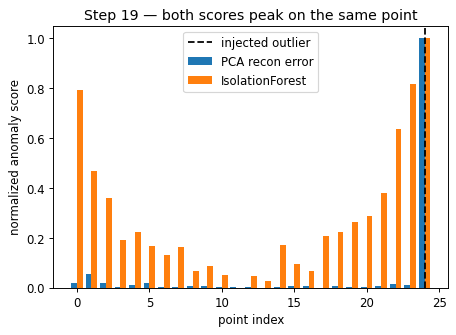

In [49]:
def minmax(a):
    return (a - a.min()) / (a.max() - a.min())

pca_norm = minmax(pca_anom_score)
iso_norm = minmax(iso_score)
combined = (pca_norm + iso_norm) / 2
combined_top = int(combined.argmax())
log("normalized PCA scores", np.round(pca_norm, 3).tolist())
log("normalized IsolationForest scores", np.round(iso_norm, 3).tolist())
log("combined top index", combined_top)
assert combined_top == outlier_index
assert pca_norm[outlier_index] == 1.0 and iso_norm[outlier_index] == 1.0

x = np.arange(len(X_anom))
plt.bar(x - 0.2, pca_norm, width=0.4, label="PCA recon error")
plt.bar(x + 0.2, iso_norm, width=0.4, label="IsolationForest")
plt.axvline(outlier_index, color="black", linestyle="--", label="injected outlier")
plt.title("Step 19 — both scores peak on the same point")
plt.xlabel("point index")
plt.ylabel("normalized anomaly score")
plt.legend(); plt.show()

**Good for:** PCA reconstruction error when normal data lives near a lower-dimensional pattern; IsolationForest when you want a general-purpose tabular anomaly baseline.  
**Watch out for:** thresholds are business decisions. A high score says "unusual," not automatically "bad" or "fraud."

---
## Recap — the whole module as one chain

1. Start with many features and ask **why reduce?** Visualization, denoising, speed, and the curse of dimensionality.
2. For linear/global compression, use **PCA**: center → covariance → eigenvectors → sort → project → check explained variance.
3. To denoise or detect weird points, reconstruct from fewer components and inspect **reconstruction error**.
4. For 2D maps of local neighborhoods, use **t-SNE** here; use **UMAP** conceptually when `umap-learn` is available and you want a fast neighbor-graph layout.
5. For anomalies, compare PCA reconstruction error with a general detector such as **IsolationForest**.

**Decision guide:** linear/global compression → PCA · local-structure visualization → t-SNE/UMAP · anomaly detection → reconstruction error / IsolationForest.